# Manual picking with xpick

The picker in notebook 03 labelled a hundred thousand channels in seconds.
It was also wrong in places, and you cannot tell which places without
looking. This notebook closes that loop with
[xpick](https://github.com/xdas-dev/xpick), a browser viewer for arrays far
too large to plot, which reads the same files Xdas writes.

The workflow is not "pick everything by hand". It is:

1. let the model propose,
2. correct what it got wrong,
3. export, and treat the result as ground truth.

Which is also exactly how you build a training or validation set.

In [1]:
import io
import subprocess
import time

import httpx
import pandas as pd

import xdas as xd

## Starting the viewer

From a terminal you would run:

```
xpick outputs/singlecable.nc
```

Started from the notebook instead, so that the rest of the cells can talk to
it. It serves a normal web page — open the URL it prints:

In [2]:
import sys

PORT = 5099
server = subprocess.Popen(
    [sys.executable, "-m", "xpick", "outputs/singlecable.nc", "--port", str(PORT)],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

BASE = f"http://127.0.0.1:{PORT}"
for _ in range(60):
    try:
        httpx.get(f"{BASE}/api/arrays", timeout=1.0)
        break
    except httpx.HTTPError:
        time.sleep(1.0)
else:
    raise RuntimeError(f"xpick did not start:\n{server.communicate()[0]}")

print(f"xpick is running -> {BASE}")

xpick is running -> http://127.0.0.1:5099


xpick never loads the whole array. It builds a pyramid of 512×512 tiles on
demand and caches them, so panning a 750-million-sample file is as smooth as
panning a photograph:

In [3]:
httpx.get(f"{BASE}/api/arrays", timeout=30).json()

[{'code': 'outputs/singlecable.nc',
  'dims': ['time', 'distance'],
  'shape': [37500, 10000],
  'coords': {'time': {'kind': 'datetime',
    'start': 1699014001000.0,
    'step': 16.0,
    'size': 37500},
   'distance': {'kind': 'numeric',
    'start': 0.0,
    'step': 15.31950286162022,
    'size': 10000}},
  'tile': 512,
  'max_levels': [7, 5]}]

## Seeding it with the model's picks

Rather than start from a blank slate, push in what PhaseNet already found.
`/api/import` takes a CSV with `time`, `distance` and `phase`, and creates
one *horizon* — a polyline across channels — per phase label.

We thin the picks first: a horizon is a handful of vertices that xpick
interpolates between, not one point per channel.

In [4]:
picks = pd.read_csv("outputs/picks.csv", parse_dates=["time"])
seed = picks[picks["phase"] == "P"].sort_values("distance").iloc[::50]

response = httpx.post(
    f"{BASE}/api/import",
    json={
        "array": "outputs/singlecable.nc",
        "csv": seed[["time", "distance", "phase"]].to_csv(index=False),
        "annotator": "phasenet",
        "kind": "model",
    },
    timeout=60,
)
print(len(seed), "vertices ->", response.json())

42 vertices -> {'ids': ['a6bf6961-6c6c-4410-afe0-449d448b9de5']}


## Now go and pick

Open the page. You should see the earthquake, with the model's P horizon
drawn across it. From here it is mouse work:

- **drag** to pan, **scroll** to zoom, and the tiles sharpen as you go in;
- **click** on a horizon to select it, then drag its vertices to move them,
  click on the line to insert one, or right-click to delete;
- **draw a new horizon** for a phase the model missed entirely — the S
  arrival on the far half of the cable is a good candidate;
- horizons carry a **status**, so you can mark one `rejected` instead of
  deleting it, which is what you want if you are measuring how often the
  model is wrong.

Everything is saved as you go, in a SQLite file under the workspace
directory — nothing is lost if the browser or the kernel dies.

## Reading the result back

`/api/export` returns one row **per channel**, interpolating along each
horizon. So a dozen hand-placed vertices come back as a pick on every single
channel they span:

In [5]:
response = httpx.get(
    f"{BASE}/api/export", params={"array": "outputs/singlecable.nc"}, timeout=120
)
corrected = pd.read_csv(io.StringIO(response.text), parse_dates=["time"])
corrected.to_csv("outputs/picks_manual.csv", index=False)
corrected

,time,distance,phase,horizon,annotator,status
0,2023-11-03 12:26:55.168000000,30010.906106,P,a6bf6961-6c6c-4410-afe0-449d448b9de5,phasenet,accepted
1,2023-11-03 12:26:55.162400000,30026.225609,P,a6bf6961-6c6c-4410-afe0-449d448b9de5,phasenet,accepted
2,2023-11-03 12:26:55.156800000,30041.545112,P,a6bf6961-6c6c-4410-afe0-449d448b9de5,phasenet,accepted
3,2023-11-03 12:26:55.151200000,30056.864614,P,a6bf6961-6c6c-4410-afe0-449d448b9de5,phasenet,accepted
4,2023-11-03 12:26:55.145600000,30072.184117,P,a6bf6961-6c6c-4410-afe0-449d448b9de5,phasenet,accepted
...,...,...,...,...,...,...
1936,2023-11-03 12:26:55.957056768,59669.463646,P,a6bf6961-6c6c-4410-afe0-449d448b9de5,phasenet,accepted
1937,2023-11-03 12:26:55.947245312,59684.783149,P,a6bf6961-6c6c-4410-afe0-449d448b9de5,phasenet,accepted
1938,2023-11-03 12:26:55.937434112,59700.102652,P,a6bf6961-6c6c-4410-afe0-449d448b9de5,phasenet,accepted
1939,2023-11-03 12:26:55.927622656,59715.422155,P,a6bf6961-6c6c-4410-afe0-449d448b9de5,phasenet,accepted


The `horizon`, `annotator` and `status` columns are what make this a dataset
rather than a pile of points: you can tell which picks came from the model,
which a human touched, and which were thrown out.

In [6]:
corrected.groupby(["phase", "annotator", "status"]).size()

phase  annotator  status  
P      phasenet   accepted    1941
dtype: int64

## Comparing with the model

Both pick sets are indexed by channel, so the residual is a subtraction:

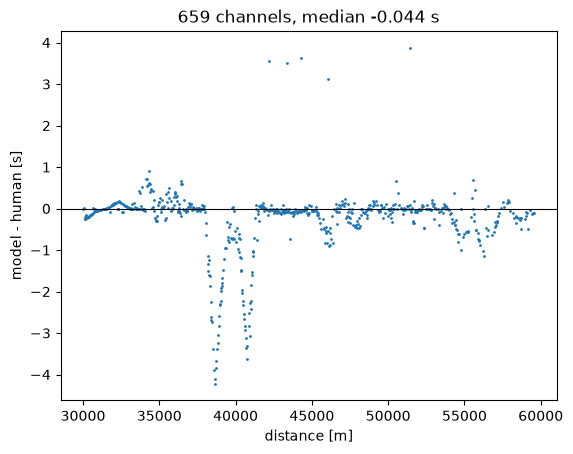

In [7]:
import matplotlib.pyplot as plt

# the earliest P per channel, since a channel may carry more than one
model_p = picks[picks["phase"] == "P"].groupby("distance")["time"].min()
human_p = corrected[corrected["phase"] == "P"].groupby("distance")["time"].min()

common = model_p.index.intersection(human_p.index)
residual = (model_p[common] - human_p[common]).dt.total_seconds()

plt.plot(common, residual, ".", ms=2)
plt.axhline(0.0, color="k", lw=0.8)
plt.xlabel("distance [m]")
plt.ylabel("model - human [s]")
plt.title(f"{len(common)} channels, median {residual.median():+.3f} s")
plt.show()

If you ran this notebook straight through without touching the browser,
that residual is not measuring a human at all — it is measuring how much the
polyline lost by keeping only every fiftieth pick. Which is a useful number
in its own right, and a good check that the round trip is faithful. Go back,
move a few vertices, and re-run the last three cells to see the difference.

## Stopping the server

In [8]:
server.terminate()
server.wait(timeout=10)
print("stopped")

stopped


```{note}
xpick opens whatever Xdas opens, including a whole `DataCollection`, and
takes several paths at once:

```
xpick "data/gps_multicable/*/*/*.hdf5" --workspace ./picking
```

`--workspace` is worth setting explicitly for real work: it is where the
tile cache and the annotation database live, and pointing several people at
the same one is how you share a picking session.
```